In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import resample_poly


In [2]:
from pathlib import Path

In [3]:
def iq_plot(i_signal, q_signal, title="IQ Plot", xlabel="I", ylabel="Q"):
    plt.scatter(i_signal, q_signal)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    #plt.show()

def plot_power(signal, f, title="Signal Power [dB]", xlabel="Frequency", ylabel="dB"):
    N = signal.shape[0]
    freq = np.linspace(-f/2, f/2, N)
    fft_signal = np.fft.fft(signal)
    power_signal = 10 * np.log10(np.fft.fftshift(np.abs(fft_signal)))
    plt.plot(freq, power_signal)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    #plt.show()

def get_spectogram(x, sample_rate=5e6, fft_size=1024, title="Spectrogram", xlabel="Frequency [MHz]", ylabel="Time [s]"):
    num_rows = len(x) // fft_size
    spectrogram = np.zeros((num_rows, fft_size))
    for i in range(num_rows):
        spectrogram[i, :] = 10 * np.log10(np.abs(np.fft.fftshift(np.fft.fft(x[i*fft_size:(i+1)*fft_size])))**2)

    plt.imshow(spectrogram, aspect='auto', extent=[-sample_rate/2/1e6, sample_rate/2/1e6, 0, len(x)/sample_rate])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    #plt.show()



# Load Data

In [4]:
PATH = "data"

# Frequency= 2460 MHz
# RF Bandwidth = 25 MHz
FILE = "capture_2460mhz"

# Frequency= 102.5 MHz
# RF Bandwidth = 5 MHz
#FILE = "capture_102_5mhz"

# Frequency= 848 MHz
# RF Bandwidth = 10 MHz
#FILE = "capture_848mhz"

In [5]:
path = Path(PATH)
data = np.loadtxt(path/FILE, skiprows=1)

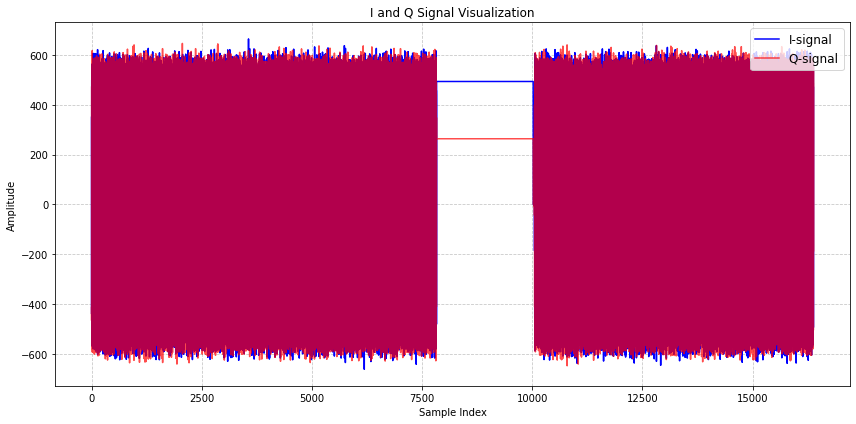

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(data[:,0], label="I-signal", color="blue", linewidth=1.5)
plt.plot(data[:,1], label="Q-signal", color="red", alpha=0.7, linewidth=1.5)
plt.title("I and Q Signal Visualization")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc="upper right", fontsize='large')
plt.tight_layout()
plt.show()

# Data Conditioning

### Descripción General del Proceso

Este fragmento de código ilustra un paso fundamental en el procesamiento de señales digitales, donde se trabaja con señales en formato complejo. A continuación se explica el proceso de manera más general:

1. **Conversión a Formato Complejo**:
   - Las señales de radiofrecuencia a menudo se representan mediante dos componentes: la componente en fase (I) y la componente en cuadratura (Q). Estas dos componentes se combinan para formar una señal compleja, que es una representación matemática conveniente para el análisis de señales.

2. **Componentes I y Q**:
   - A partir de la señal compleja, se pueden extraer las partes real e imaginaria, que corresponden a las señales I y Q, respectivamente. Estas componentes son esenciales para entender cómo se modula y demodula la señal.

3. **Cálculo de la Señal Recibida**:
   - Se utiliza una función para calcular la señal recibida (`rx_signal`). Esta función toma las señales I y Q y las combina para obtener una representación de la señal en el tiempo. Este paso es crucial para analizar cómo se comporta la señal en un sistema de comunicación.

In [7]:
# Step 0: Transform data into complex format
f = 
rx = data[:,0] + data[:,1]*1j
# Create IQ components
i_signal = np.real(rx)
q_signal = np.imag(rx)

def compute_rx_signal(i_signal, q_signal, f):
    N = len(i_signal)
    t = np.arange(N) / f
    rx = i_signal + q_signal * 1j
    amplitude = np.sqrt(i_signal**2 + q_signal**2)
    rx_signal = np.abs(rx) * np.cos(2 * np.pi * f * t + np.angle(rx))
    return rx_signal

rx_signal = 

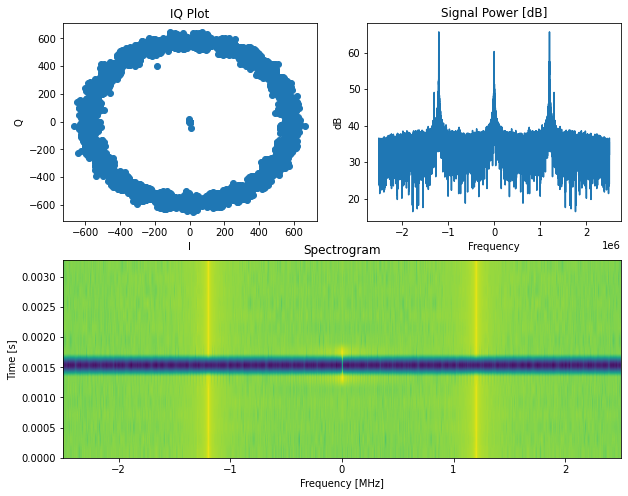

In [8]:
def plot_signals(i_signal, q_signal, rx_signal, f, sample_rate=5e6, fft_size=1024):
    plt.figure(figsize=(10, 8))

    plt.subplot(2, 2, 1)
    iq_plot(i_signal, q_signal)

    plt.subplot(2, 2, 2)
    plot_power(rx_signal, f)

    plt.subplot(2, 1, 2)
    get_spectogram(rx_signal, sample_rate=sample_rate, fft_size=fft_size)

    plt.show()

plot_signals(i_signal, q_signal, rx_signal, f)

### Explicación General de la Etapa

En esta etapa del procesamiento de señales digitales, se realizan dos pasos clave para preparar las señales I (in-phase) y Q (quadrature) para un análisis más detallado. Estos pasos son fundamentales para mejorar la calidad de la señal y facilitar su posterior procesamiento:

1. **Normalización de las Señales I y Q**:
   - La normalización es un proceso que ajusta la amplitud de las señales I y Q para que sus valores estén dentro de un rango estándar. Esto se logra dividiendo cada señal por su valor máximo absoluto. La normalización es importante porque asegura que las señales tengan una escala uniforme, lo que facilita su comparación y análisis.

2. **Filtrado de las Señales para Eliminar Ruido**:
   - El filtrado es un proceso que elimina el ruido no deseado de las señales. En este caso, se utiliza un filtro pasa-bajos (low-pass filter) para eliminar las frecuencias altas que pueden ser ruido. 
   - Se define una frecuencia de corte (cutoff frequency) que determina el límite superior de las frecuencias que se permitirán pasar. Las frecuencias por encima de este límite se atenúan.
   - El filtrado mejora la calidad de la señal al reducir el ruido, lo que es crucial para obtener mediciones precisas y fiables.

Estos pasos son esenciales en el procesamiento de señales digitales, especialmente en aplicaciones de comunicación, donde la calidad de la señal puede afectar significativamente el rendimiento del sistema.


In [9]:
# Step 1: Normalize the I and Q signals
i_signal_normalized = 
q_signal_normalized = 

# Step 2: Filter the signals to remove noise
from scipy.signal import butter, lfilter

def butter_lowpass(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = lfilter(b, a, data)
    return y

cutoff_frequency = 
sampling_frequency = 

i_signal_filtered = 
q_signal_filtered = 

rx_signal_filtered = 

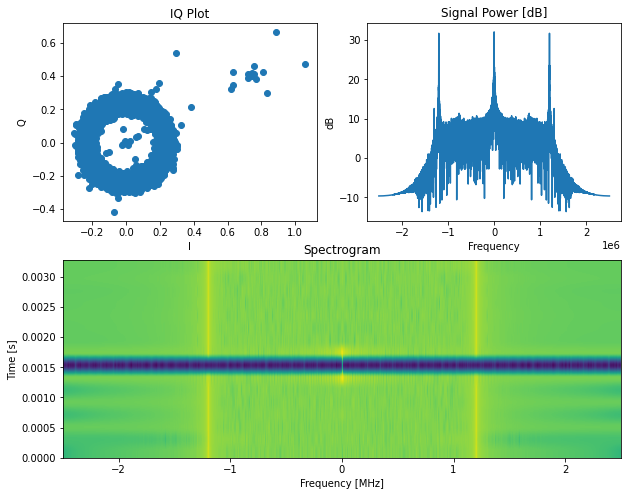

In [10]:
plot_signals(i_signal_filtered, q_signal_filtered, rx_signal_filtered, sampling_frequency)

### Explicación de la Etapa de Downsampling

En esta etapa del procesamiento de señales digitales, se realiza el proceso de **downsampling** o submuestreo de las señales I (in-phase) y Q (quadrature). Este proceso es crucial para reducir la cantidad de datos y simplificar el análisis posterior. A continuación se explica el proceso:

1. **Downsampling de las Señales I y Q**:
   - El downsampling es el proceso de reducir la tasa de muestreo de una señal. En este caso, se utiliza un factor de submuestreo (`downsample_factor`) de 10.
   - Las señales I y Q filtradas (`i_signal_filtered` y `q_signal_filtered`) se submuestrean tomando cada décimo valor. Esto se realiza utilizando la notación de slicing en Python (`[::downsample_factor]`).

2. **Cálculo de la Señal Recibida Submuestreada**:
   - Después de submuestrear las señales I y Q, se calcula la señal recibida (`rx_signal_downsampled`) utilizando la función `compute_rx_signal`.
   - La frecuencia de muestreo se ajusta dividiendo la frecuencia original por el factor de submuestreo.

El downsampling es una técnica útil para reducir la cantidad de datos a procesar, lo que puede mejorar la eficiencia computacional y facilitar el análisis de señales en sistemas de comunicación.


In [11]:
# Step 3: Downsample the signals
downsample_factor = 
i_signal_downsampled = 
q_signal_downsampled = 

rx_signal_downsampled = 


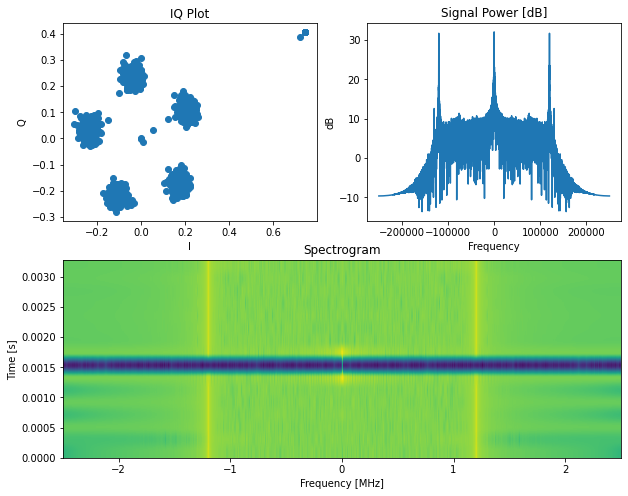

In [12]:
plot_signals(i_signal_downsampled, q_signal_downsampled, 
             rx_signal_downsampled, sampling_frequency/downsample_factor)

### Explicación del Código: Sincronización Temporal con el Método de Mueller y Müller

Este fragmento de código implementa la sincronización temporal de señales I (in-phase) y Q (quadrature) utilizando el método de Mueller y Müller. Este método es una técnica de recuperación de temporización utilizada en sistemas de comunicación digital para alinear correctamente las muestras de la señal. A continuación se explica el proceso:

1. **Definición de la Función `mueller_muller_timing_recovery`**:
   - La función toma como entrada las señales I y Q, el número de muestras por símbolo (`sps`), y parámetros de control como `mu` (fase de muestreo inicial) y `gain` (ganancia del lazo de control).
   - Se inicializan vectores para almacenar las señales sincronizadas (`i_signal_synced` y `q_signal_synced`) y una variable para el error de temporización (`timing_error`).

2. **Bucle de Sincronización**:
   - Se recorre la señal, ajustando la fase de muestreo `mu` en cada iteración.
   - Las señales sincronizadas se obtienen tomando muestras de las señales I y Q en los puntos determinados por `mu`.
   - Se calcula el error de temporización basado en las diferencias entre muestras adyacentes, lo que ayuda a ajustar `mu` para mejorar la sincronización.

3. **Ajuste de la Fase de Muestreo**:
   - La fase de muestreo `mu` se actualiza en cada iteración utilizando el error de temporización multiplicado por la ganancia (`gain`).
   - `mu` se ajusta para mantenerse dentro del rango de muestras por símbolo (`sps`).

4. **Aplicación de la Función**:
   - Se llama a la función `mueller_muller_timing_recovery` con las señales I y Q submuestreadas, y el número de muestras por símbolo (`sps`).
   - Se calcula la señal recibida sincronizada (`rx_signal_synced`) utilizando las señales I y Q sincronizadas.

Este proceso es crucial para asegurar que las señales I y Q estén correctamente alineadas en el tiempo, lo que es esencial para una correcta demodulación y recuperación de datos en sistemas de comunicación digital.


In [13]:
# Step 4: Perform time synchronization using the Mueller and Müller method
def mueller_muller_timing_recovery(i_signal, q_signal, sps, mu=0.5, gain=0.01):
    n = len(i_signal)
    i_signal_synced = np.zeros(n)
    q_signal_synced = np.zeros(n)
    timing_error = 0.0
    for i in range(n - sps):
        i_signal_synced[i] = i_signal[i + int(mu)]
        q_signal_synced[i] = q_signal[i + int(mu)]
        timing_error = (i_signal[i + int(mu)] * (i_signal[i + int(mu) + 1] - i_signal[i + int(mu) - 1]) +
                        q_signal[i + int(mu)] * (q_signal[i + int(mu) + 1] - q_signal[i + int(mu) - 1]))
        mu += gain * timing_error
        mu = mu % sps
    return i_signal_synced, q_signal_synced

sps =   # Samples per symbol, adjust as needed
i_signal_synced, q_signal_synced = 
rx_signal_synced = 

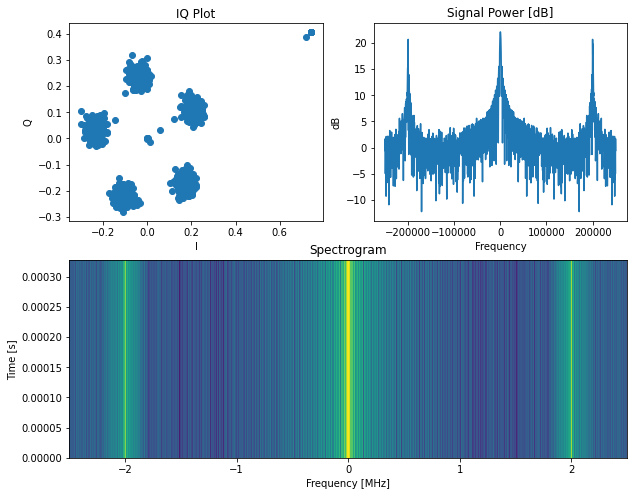

In [14]:
plot_signals(i_signal_synced, q_signal_synced, 
             rx_signal_synced, sampling_frequency/downsample_factor)

## Explicación del Código: Sincronización de Frecuencia

Este código se utiliza para corregir el desfase de frecuencia en una señal digital, un paso crucial en el procesamiento de señales para asegurar una correcta demodulación y recuperación de datos.

### Estimación del Desfase de Frecuencia

La función `estimate_frequency_offset` utiliza la Transformada Rápida de Fourier (FFT) para identificar el componente de frecuencia dominante en la señal, lo que permite calcular el desfase de frecuencia.

### Corrección del Desfase de Frecuencia

La función `frequency_synchronization` corrige el desfase de frecuencia multiplicando la señal por una señal de corrección, que es una exponencial compleja diseñada para compensar el desfase estimado.

### Resumen

- **Estimación**: Se estima el desfase de frecuencia usando FFT.
- **Corrección**: Se aplica una señal de corrección para alinear la señal en frecuencia.

Este proceso es esencial para asegurar que las señales digitales estén correctamente alineadas en frecuencia, lo que es crucial para el correcto funcionamiento de los sistemas de comunicación digital.

In [15]:
# Step 5: Perform frequency synchronization with estimation
def estimate_frequency_offset(rx_signal, fs):
    # Use the FFT method to estimate frequency offset
    n = len(rx_signal)
    freq_spectrum = np.fft.fftshift(np.fft.fft(rx_signal))
    freq_axis = np.fft.fftshift(np.fft.fftfreq(n, d=1/fs))
    peak_index = np.argmax(np.abs(freq_spectrum))
    estimated_offset = freq_axis[peak_index]
    return estimated_offset

frequency_offset_estimate = 

# Define the frequency_synchronization function
def frequency_synchronization(rx_signal, fs, frequency_offset):
    # Correct the frequency offset
    n = len(rx_signal)
    t = np.arange(n) / fs
    correction_signal = np.exp(-1j * 2 * np.pi * frequency_offset * t)
    return rx_signal * correction_signal

rx_synced = 

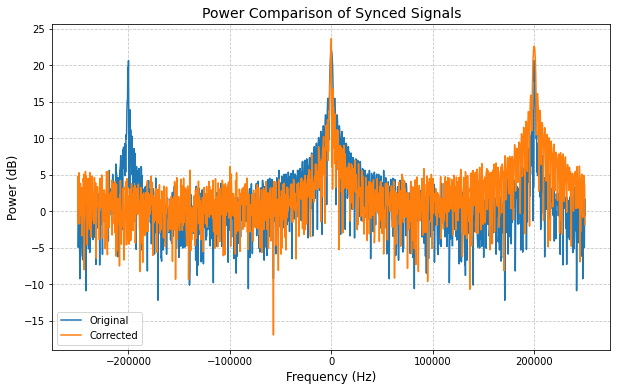

In [16]:
plt.figure(figsize=(10, 6))
plot_power(rx_signal_synced, sampling_frequency/downsample_factor)
plot_power(rx_synced, sampling_frequency/downsample_factor)
plt.title('Power Comparison of Synced Signals', fontsize=14)
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Power (dB)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(["Original", "Corrected"])
plt.show()

## Explicación del Código: Recuperación de Símbolos

Este fragmento de código se encarga de recuperar los símbolos transmitidos a partir de una señal recibida, asumiendo una modulación BPSK/QPSK.

### Función `recover_symbols`

- **Propósito**: Extraer los símbolos transmitidos de la señal recibida.
- **Método**: 
  - Se asume que la señal está modulada usando BPSK o QPSK.
  - La función toma muestras de la señal recibida (`rx_signal`) a intervalos definidos por `sps` (muestras por símbolo).
  - Utiliza la función `np.sign` para determinar el signo de las partes real e imaginaria de los símbolos, lo que ayuda a identificar los símbolos transmitidos.

### Resumen

- **Recuperación**: Se extraen los símbolos de la señal recibida a intervalos regulares.
- **Modulación**: Se asume BPSK/QPSK para simplificar el proceso de recuperación.

Este proceso es fundamental para decodificar la información transmitida en sistemas de comunicación digital.


In [17]:
# Step 6: Recover transmitted symbols
def recover_symbols(rx_signal, sps):
    # Assuming BPSK/QPSK modulation for simplicity
    symbols = rx_signal[::sps]
    return np.sign(np.real(symbols)) + 1j * np.sign(np.imag(symbols))

recovered_symbols = 

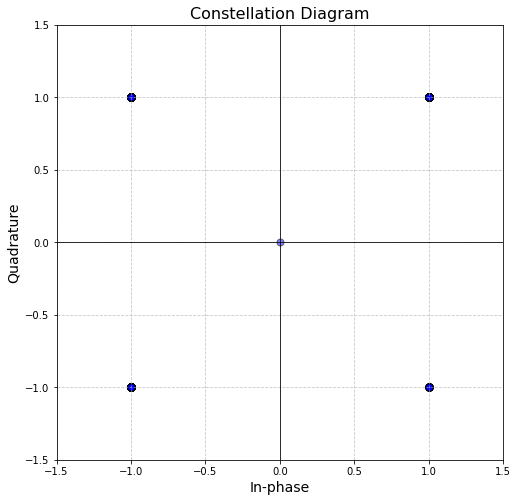

In [18]:
i_signal_recovered = np.real(recovered_symbols)
q_signal_recovered = np.imag(recovered_symbols)

plt.figure(figsize=(8, 8))
plt.scatter(i_signal_recovered, q_signal_recovered, color='blue', alpha=0.5, edgecolor='k', s=50)
plt.title('Constellation Diagram', fontsize=16)
plt.xlabel('In-phase', fontsize=14)
plt.ylabel('Quadrature', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.show()

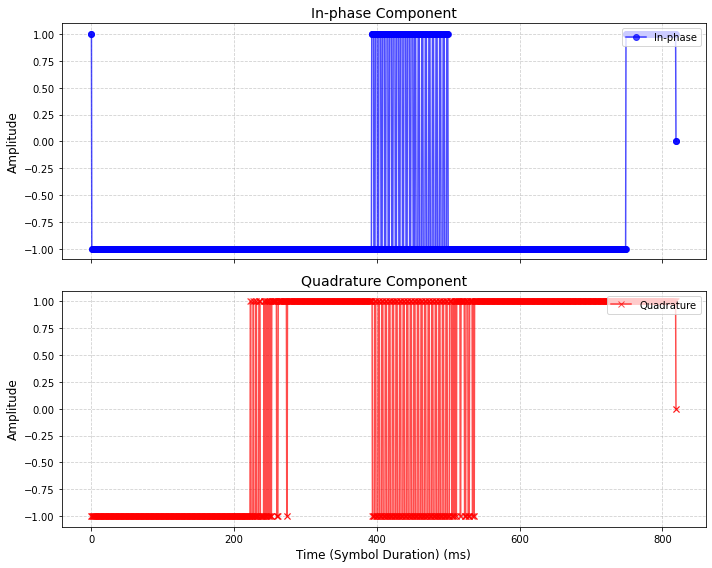

In [19]:
def plot_qpsk_data_transmission(recovered_symbols, sps):
    """
    Plot the recovered symbols as a message for QPSK data transmission with pulse width.

    Parameters:
    recovered_symbols (np.ndarray): The array of recovered symbols.
    sps (int): Samples per symbol, used to emulate the time duration of each pulse.

    Returns:
    None
    """
    # Create a time vector to emulate pulse width
    time_vector = np.arange(len(recovered_symbols) * sps) / sps
    
    # Repeat each symbol sps times to emulate pulse width
    in_phase = np.repeat(np.real(recovered_symbols), sps)
    quadrature = np.repeat(np.imag(recovered_symbols), sps)
    
    # Create a vertical grid for separate plots
    fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    # Plot In-phase component
    axs[0].plot(time_vector, in_phase, label='In-phase', linestyle='-', marker='o', color='b', alpha=0.7)
    axs[0].set_title('In-phase Component', fontsize=14)
    axs[0].set_ylabel('Amplitude', fontsize=12)
    axs[0].legend(loc='upper right', fontsize=10)
    axs[0].grid(True, linestyle='--', alpha=0.6)
    
    # Plot Quadrature component
    axs[1].plot(time_vector, quadrature, label='Quadrature', linestyle='-', marker='x', color='r', alpha=0.7)
    axs[1].set_title('Quadrature Component', fontsize=14)
    axs[1].set_xlabel('Time (Symbol Duration) (ms)', fontsize=12)
    axs[1].set_ylabel('Amplitude', fontsize=12)
    axs[1].legend(loc='upper right', fontsize=10)
    axs[1].grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# Call the function with the recovered symbols and samples per symbol
plot_qpsk_data_transmission(recovered_symbols, sps)